In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rifatulmajumder23/combined-unknown-pneumonia-and-tuberculosis/data/dataset_splits_with_metadata.csv
/kaggle/input/datasets/rifatulmajumder23/combined-unknown-pneumonia-and-tuberculosis/data/val/UNKNOWN/horse-111.jpg
/kaggle/input/datasets/rifatulmajumder23/combined-unknown-pneumonia-and-tuberculosis/data/val/UNKNOWN/rider-82.jpg
/kaggle/input/datasets/rifatulmajumder23/combined-unknown-pneumonia-and-tuberculosis/data/val/UNKNOWN/horse-79.jpg
/kaggle/input/datasets/rifatulmajumder23/combined-unknown-pneumonia-and-tuberculosis/data/val/UNKNOWN/horse-133.jpg
/kaggle/input/datasets/rifatulmajumder23/combined-unknown-pneumonia-and-tuberculosis/data/val/UNKNOWN/rider-6.jpg
/kaggle/input/datasets/rifatulmajumder23/combined-unknown-pneumonia-and-tuberculosis/data/val/UNKNOWN/cat.17.jpg
/kaggle/input/datasets/rifatulmajumder23/combined-unknown-pneumonia-and-tuberculosis/data/val/UNKNOWN/rider-202.jpg
/kaggle/input/datasets/rifatulmajumder23/combined-unknown-pneumonia-and-

In [2]:
train_dir = "/kaggle/input/datasets/rifatulmajumder23/combined-unknown-pneumonia-and-tuberculosis/data/train"
test_dir = "/kaggle/input/datasets/rifatulmajumder23/combined-unknown-pneumonia-and-tuberculosis/data/test"
val_dir = "/kaggle/input/datasets/rifatulmajumder23/combined-unknown-pneumonia-and-tuberculosis/data/val"

In [5]:
import tensorflow as tf

In [6]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(300, 300),
    batch_size=32,
    shuffle=True
)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(300, 300),
    batch_size=32,
    shuffle=True
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(300, 300),
    batch_size=32,
    shuffle=True
)

Found 13028 files belonging to 4 classes.


I0000 00:00:1773731057.868960      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773731057.875071      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1527 files belonging to 4 classes.
Found 761 files belonging to 4 classes.


In [7]:
class_names = train_dataset.class_names
print(class_names)

['NORMAL', 'PNEUMONIA', 'TUBERCULOSIS', 'UNKNOWN']


In [8]:
for images, labels in train_dataset.take(1):
    print(images.shape)
    print(labels.shape)

(32, 300, 300, 3)
(32,)


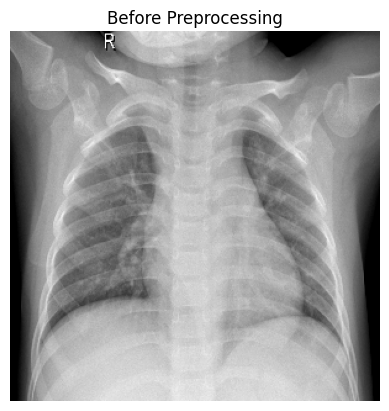

In [10]:
import matplotlib.pyplot as plt



for images, labels in train_dataset.take(1):

    img = images[11].numpy()

    plt.imshow(img.astype("uint8"))
    plt.title("Before Preprocessing")
    plt.axis("off")
    plt.show()

## Preprocessing

In [11]:
IMG_SIZE = 300

def crop_lung_region(image, label):

    h = tf.shape(image)[0]
    w = tf.shape(image)[1]

    crop_ratio = 0.05

    crop_top = tf.cast(crop_ratio * tf.cast(h, tf.float32), tf.int32)
    crop_left = tf.cast(crop_ratio * tf.cast(w, tf.float32), tf.int32)

    crop_height = tf.cast((1 - 2 * crop_ratio) * tf.cast(h, tf.float32), tf.int32)
    crop_width = tf.cast((1 - 2 * crop_ratio) * tf.cast(w, tf.float32), tf.int32)

    image = tf.image.crop_to_bounding_box(
        image,
        crop_top,
        crop_left,
        crop_height,
        crop_width
    )

    return image, label

In [12]:
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers

In [13]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

In [14]:
def preprocess_image(image, label):

    image, label = crop_lung_region(image, label)

    image = tf.image.resize(image, (300,300))

    image = tf.cast(image, tf.float32)

    image = preprocess_input(image)

    return image, label

In [15]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = []

for images, label in train_dataset:
    labels.extend(label.numpy())

labels = np.array(labels)

print(labels)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

[1 1 1 ... 0 1 2]
{0: np.float64(0.6978787229483608), 1: np.float64(0.896504266446463), 2: np.float64(0.9115589140778058), 3: np.float64(2.8199134199134197)}


In [16]:
train_dataset_des = train_dataset.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset_des = val_dataset.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset_des = train_dataset_des.prefetch(tf.data.AUTOTUNE)
val_dataset_des = val_dataset_des.prefetch(tf.data.AUTOTUNE)

In [24]:
## learning rate scduller and Earlystopping and Class_weights
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

Early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=1,
    restore_best_weights=True
)


lr_scduller = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr = 1e-6
)


In [25]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import Dense, Dropout

In [26]:
base_model = EfficientNetB3(
    weights="imagenet",
    include_top=False,
    input_shape=(300,300,3)
)

In [27]:
base_model.trainable = False

In [28]:
# model building

inputs = tf.keras.Input(shape=(300,300,3))

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = Dense(256,activation="relu")(x)

x = tf.keras.layers.BatchNormalization()(x)

x = Dropout(0.3)(x)

outputs = Dense(4,activation="softmax")(x)

model = tf.keras.Model(inputs,outputs)

In [29]:
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),loss=tf.keras.losses.SparseCategoricalCrossentropy(),metrics=['accuracy'])


In [30]:
# Fit model
history = model.fit(
    train_dataset_des,
    validation_data=val_dataset_des,
    epochs=25,
    callbacks=[Early_stopping, lr_scduller],
    class_weight=class_weights
)

Epoch 1/25


E0000 00:00:1773732424.503387      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_2_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


408/408 ━━━━━━━━━━━━━━━━━━━━ 126s 269ms/step - accuracy: 0.7517 - loss: 0.5720 - val_accuracy: 0.8476 - val_loss: 0.3499 - learning_rate: 0.0010
Epoch 2/25
408/408 ━━━━━━━━━━━━━━━━━━━━ 109s 266ms/step - accuracy: 0.8433 - loss: 0.3342 - val_accuracy: 0.8778 - val_loss: 0.3000 - learning_rate: 0.0010
Epoch 3/25
408/408 ━━━━━━━━━━━━━━━━━━━━ 109s 267ms/step - accuracy: 0.8558 - loss: 0.2995 - val_accuracy: 0.8988 - val_loss: 0.2562 - learning_rate: 0.0010
Epoch 4/25
408/408 ━━━━━━━━━━━━━━━━━━━━ 110s 268ms/step - accuracy: 0.8698 - loss: 0.2865 - val_accuracy: 0.8830 - val_loss: 0.2704 - learning_rate: 0.0010
Epoch 5/25
408/408 ━━━━━━━━━━━━━━━━━━━━ 141s 266ms/step - accuracy: 0.8721 - loss: 0.2618 - val_accuracy: 0.8975 - val_loss: 0.2452 - learning_rate: 0.0010
Epoch 6/25
408/408 ━━━━━━━━━━━━━━━━━━━━ 110s 268ms/step - accuracy: 0.8847 - loss: 0.2330 - val_accuracy: 0.9041 - val_loss: 0.2409 - learning_rate: 0.0010
Epoch 7/25
408/408 ━━━━━━━━━━━━━━━━━━━━ 110s 268ms/step - accuracy: 0.8836 

## Finetunning Last layers (30)

In [31]:
base_model.trainable = True

In [32]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [33]:
for layer in base_model.layers:
    print(layer.name, layer.trainable)

input_layer_3 False
rescaling_2 False
normalization_1 False
rescaling_3 False
stem_conv_pad False
stem_conv False
stem_bn False
stem_activation False
block1a_dwconv False
block1a_bn False
block1a_activation False
block1a_se_squeeze False
block1a_se_reshape False
block1a_se_reduce False
block1a_se_expand False
block1a_se_excite False
block1a_project_conv False
block1a_project_bn False
block1b_dwconv False
block1b_bn False
block1b_activation False
block1b_se_squeeze False
block1b_se_reshape False
block1b_se_reduce False
block1b_se_expand False
block1b_se_excite False
block1b_project_conv False
block1b_project_bn False
block1b_drop False
block1b_add False
block2a_expand_conv False
block2a_expand_bn False
block2a_expand_activation False
block2a_dwconv_pad False
block2a_dwconv False
block2a_bn False
block2a_activation False
block2a_se_squeeze False
block2a_se_reshape False
block2a_se_reduce False
block2a_se_expand False
block2a_se_excite False
block2a_project_conv False
block2a_project_bn F

In [41]:
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),loss=tf.keras.losses.SparseCategoricalCrossentropy(),metrics=['accuracy'])

In [42]:

Early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    verbose=1,
    restore_best_weights=True
)


lr_scduller = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr = 1e-6
)


In [43]:
# Fit model
history = model.fit(
    train_dataset_des,
    validation_data=val_dataset_des,
    epochs=13,
    callbacks=[Early_stop, lr_scduller],
    class_weight=class_weights
)

Epoch 1/13


E0000 00:00:1773734841.638135      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_2_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


408/408 ━━━━━━━━━━━━━━━━━━━━ 146s 307ms/step - accuracy: 0.7543 - loss: 0.6228 - val_accuracy: 0.8660 - val_loss: 0.3280 - learning_rate: 1.0000e-05
Epoch 2/13
408/408 ━━━━━━━━━━━━━━━━━━━━ 124s 304ms/step - accuracy: 0.8363 - loss: 0.3640 - val_accuracy: 0.8883 - val_loss: 0.2799 - learning_rate: 1.0000e-05
Epoch 3/13
408/408 ━━━━━━━━━━━━━━━━━━━━ 126s 307ms/step - accuracy: 0.8614 - loss: 0.3152 - val_accuracy: 0.8949 - val_loss: 0.2530 - learning_rate: 1.0000e-05
Epoch 4/13
408/408 ━━━━━━━━━━━━━━━━━━━━ 126s 308ms/step - accuracy: 0.8661 - loss: 0.2855 - val_accuracy: 0.9014 - val_loss: 0.2275 - learning_rate: 1.0000e-05
Epoch 5/13
408/408 ━━━━━━━━━━━━━━━━━━━━ 126s 308ms/step - accuracy: 0.8731 - loss: 0.2749 - val_accuracy: 0.9054 - val_loss: 0.2252 - learning_rate: 1.0000e-05
Epoch 6/13
408/408 ━━━━━━━━━━━━━━━━━━━━ 126s 307ms/step - accuracy: 0.8839 - loss: 0.2514 - val_accuracy: 0.9054 - val_loss: 0.2204 - learning_rate: 1.0000e-05
Epoch 7/13
408/408 ━━━━━━━━━━━━━━━━━━━━ 126s 309ms/

## Testing using test dataset

In [44]:
def preprocess_image(image, label):

    image, label = crop_lung_region(image, label)

    image = tf.image.resize(image, (300,300))

    image = tf.cast(image, tf.float32)

    image = preprocess_input(image)

    return image, label

In [45]:
test_dataset = test_dataset.map(preprocess_image)

In [47]:
## model evluate
test_loss, test_acc = model.evaluate(test_dataset)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 231ms/step - accuracy: 0.9249 - loss: 0.2053
Test Accuracy: 0.9201048016548157
Test Loss: 0.20431853830814362


In [46]:
y_true = []
y_pred = []

for image,label in test_dataset:
    preds = model.predict(image)
    preds = preds.argmax(axis=1)
    y_true.extend(label.numpy())
    y_pred.extend(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.86      0.89       548
           1       0.89      0.96      0.92       427
           2       0.94      0.92      0.93       417
           3       0.98      1.00      0.99       135

    accuracy                           0.92      1527
   macro avg       0.93      0.94      0.93      1527
weighted avg       0.92      0.92      0.92      1527



In [51]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_true,y_pred))

[[473  49  26   0]
 [ 14 412   0   1]
 [ 29   4 382   2]
 [  0   0   0 135]]


# 🩺 Chest X-Ray Disease Classification using Deep Learning

## 📌 Project Overview

This project builds an **end-to-end deep learning pipeline** to classify chest X-ray images into four categories:

* **Normal**
* **Pneumonia**
* **Tuberculosis**
* **Non-Xray (Unknown)**

The model leverages **transfer learning with EfficientNetB3** to achieve high accuracy on medical image data.

---

## 🎯 Objective

The goal of this project is to:

* Automatically detect lung diseases from chest X-ray images
* Handle **multi-class classification** including abnormal and non-medical images
* Build a robust pipeline with **preprocessing, augmentation, and fine-tuning**

---

## 📂 Dataset

Dataset used:

* Combined Chest X-ray dataset (TB, Pneumonia, Normal, Non-Xray)

### Dataset Distribution

* **Train:** ~13,000 images
* **Validation:** ~700+ images
* **Test:** ~1500+ images

The dataset includes real-world challenges such as:

* Class imbalance
* Similar visual patterns between TB and Pneumonia
* Presence of non-Xray images

---

## ⚙️ Model Architecture

* Base Model: **EfficientNetB3 (ImageNet pretrained)**
* Input Size: **300 × 300**
* Pipeline:

```
Input Image
→ Data Augmentation
→ Preprocessing (EfficientNet)
→ EfficientNetB3 (Frozen / Fine-tuned)
→ Global Average Pooling
→ Dense (256) + BatchNorm + Dropout
→ Output Layer (Softmax - 4 classes)
```

---

## 🧠 Training Strategy

### Stage 1: Feature Extraction

* Base model frozen
* Only classifier (head) trained
* Learning Rate: `1e-4`
* Achieved Validation Accuracy: **~91%**

---

### Stage 2: Fine-Tuning

* Last ~30 layers unfrozen

* Learning Rate reduced to `1e-5`

* Used:

  * Early Stopping
  * Learning Rate Scheduler

* Achieved Validation Accuracy: **~92.7%**

---

## 📊 Evaluation Results

### ✅ Test Accuracy

* **~91–92%**

### 🔍 Confusion Matrix Insights

* Strong performance on:

  * Pneumonia
  * Tuberculosis
  * Non-Xray (100% accuracy)

* Minor confusion:

  * Normal ↔ TB / Pneumonia

This is expected due to **similar visual patterns in medical images**.

---

## 📈 Key Techniques Used

* Transfer Learning (EfficientNetB3)
* Fine-Tuning of Deep Layers
* Data Augmentation
* Batch Normalization & Dropout
* Learning Rate Scheduling
* Early Stopping

---

## 🚀 Results Summary

| Metric              | Value     |
| ------------------- | --------- |
| Validation Accuracy | ~92%      |
| Test Accuracy       | ~91–92%   |
| TB Detection Recall | ~90%+     |
| Pneumonia Detection | Very High |

---

## 💡 Key Learnings

* EfficientNet performs better than DenseNet for this dataset
* Fine-tuning must be done carefully with low learning rate
* Medical datasets require strong preprocessing and augmentation
* Accuracy alone is not enough — class-wise evaluation is important

---

## 🔮 Future Improvements

* Use **Focal Loss / Class-Balanced Loss**
* Apply **Test Time Augmentation (TTA)**
* Try **Vision Transformers (ViT)**
* Improve TB vs Normal classification

---

## 🏁 Conclusion

This project demonstrates a **robust deep learning solution for medical image classification**, achieving high accuracy while handling real-world challenges such as class imbalance and subtle disease patterns.

---


In [53]:
# Saving the model
model.save("/kaggle/working/xray_model.keras")


In [55]:
import joblib

joblib.dump(class_names,"class_names.pkl")

['class_names.pkl']

In [56]:
!zip -r model.zip /kaggle/working/xray_model.keras

  adding: kaggle/working/xray_model.keras (deflated 9%)


In [57]:
!pip install pydrive

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 987.4/987.4 kB 14.9 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for pydrive: filename=PyDrive-1.3.1-py3-none-any.whl size=27433 sha256=c3594a83e3cd8bdc1f63f3ac520bbca980bfbf9b1778e0569a41b9e87ce1a705
  Stored in directory: /root/.cache/pip/wheels/6c/10/da/a5b513f5b3916fc391c20ee7b4633e5cf3396d570cdd74970f
Successfully built pydrive


In [58]:
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

file = drive.CreateFile({'title': 'xray_model.keras'})
file.SetContentFile('/kaggle/working/xray_model.keras')
file.Upload()